# Chapter 48 — Planning a Radio Observation: Sidereal Time, Transit, and the Beam

!!! info "Before you start"
    **Prerequisites:** Ch 1 (What is Radio Astronomy?), Ch 2 (Physics of Radio Emission), Ch 3 (Signals, Noise & the Radiometer Equation), Ch 4 (Antennas & Receivers) · **Maths Lab:** [Lab D (Coordinates & Time)](34_mathslab_coordinates_time.ipynb) · **~60 min** · **Intermediate**

You have a dish. You have a target. The night is clear. Now what?

Before you can usefully point at a radio source you need to answer four
practical questions:

1. **When does it transit?** — a source is highest and most easily observed as
   it crosses your local meridian.
2. **How high does it get?** — altitude sets air-mass path length and minimum
   elevation for your mount.
3. **How long does it stay in the beam?** — a drift-scan (dish parked, sky
   turning through) only "sees" the source for a limited window.
4. **What does the chart recorder draw?** — the noise-limited trace is the
   real output of a total-power radiometer, and understanding its shape and
   amplitude is the bridge between the physics and the data.

This chapter answers all four, working each calculation **twice**: first from
first principles with the `jansky.observing` helpers (which implement the
textbook formulae directly), then cross-checking against **astropy** so you
can see that both paths agree. The contrast is the point: you should both trust
the libraries *and* understand what they are doing.

### What you'll be able to do

- Compute the **Greenwich and Local Sidereal Time** from a Julian Date, and
  explain why the sidereal clock runs $\approx$3 m 56 s per day fast on the
  Sun — the same drift Karl Jansky used to pin his mystery static to the sky.
- Calculate a source's **hour angle**, **altitude at transit**, and **time to
  transit** for any site/instant/target triple.
- Classify a source as **circumpolar**, always visible, or never rising from
  a given latitude.
- Derive the **beam-transit time** $t = \theta / (\omega_\oplus \cos\delta)$
  and understand both the "one degree $\approx$ four minutes" rule and the
  $1/\cos\delta$ stretch toward the poles.
- **Simulate a drift-scan radiometer trace** — with source flux, receiver
  noise figure, system temperature, gain, and chart speed all wired together —
  and read off the peak deflection, SNR, and transit width.

### Connections

- [Chapter 1](01_what_is_radio_astronomy.ipynb) introduced Jansky's discovery;
  the four-minutes-a-day drift is revisited here from first principles.
- [Chapter 4](04_antennas_and_receivers.ipynb) derived the beamwidth
  $\theta_\mathrm{FWHM} \approx 1.02\,\lambda/D$ and the effective area
  $A_\mathrm{eff} = \eta\,\pi D^2/4$; we use both below.
- [Maths Lab D](34_mathslab_coordinates_time.ipynb) is the worked companion on
  coordinate frames and the LSR; it links forward to this chapter for the
  practical planning payoff.


## The references

The two standing references for observation planning and telescope pointing are:

> **Meeus, J. (1998).** *Astronomical Algorithms*, 2nd ed. Willmann-Bell.
> — The authoritative numerical-astronomy handbook. Equation 12.4, which this
> chapter implements directly for GMST, is from Chapter 12 ("Sidereal Time at
> Greenwich"). Every formula involving Julian Dates and sidereal time in this
> chapter traces back here.

> **Condon, J. J. & Ransom, S. M. (2016).** *Essential Radio Astronomy.*
> Princeton University Press. Chapter 3 ("Radio Telescopes and Radiometers").
> Free online at
> [cv.nrao.edu/~sransom/web/Ch3.html](https://www.cv.nrao.edu/~sransom/web/Ch3.html).
> — The standard radio-astronomy textbook for graduate students; the transit
> altitude formula $a_\mathrm{transit} = 90^\circ - |\phi - \delta|$, the
> radiometer equation, and the drift-scan SNR are all discussed there.

The drift-scan projects in Sections 3–5 are inspired by the teacher notebook
series from NRAO/GBO:

> **NRAO / GBO (2018).** *Radio Astronomy Teachers' Notebook.* National Radio
> Astronomy Observatory / Green Bank Observatory. — A series of guided
> student projects using a 40-foot radio telescope. The transit-time, chart-
> recorder, and noise-figure projects form the pedagogical backbone of this
> chapter.
> [https://www.gb.nrao.edu/edu/edtp.shtml](https://www.gb.nrao.edu/edu/edtp.shtml)


## Setup

We disable IERS auto-download so the whole notebook is guaranteed offline, then
import `jansky.observing` and the cross-check machinery from `astropy`.


In [1]:
# Guarantee fully-offline operation: no IERS auto-download
from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None

import warnings
warnings.filterwarnings("ignore", message=".*ERFA function.*")
warnings.filterwarnings("ignore", message=".*leap second.*")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import astropy.units as u
from astropy.constants import k_B
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

# jansky helpers
from jansky import observing, signals, plotting

plotting.use_jansky_style()

# One seeded RNG so figures are reproducible
_rng_seed = 48
print("Chapter 48 — Planning a Radio Observation ready.")
print(f"jansky.observing module loaded: {observing.__name__}")


Chapter 48 — Planning a Radio Observation ready.
jansky.observing module loaded: jansky.observing


## Our running example: Green Bank, WV

Throughout this chapter we use the site of the **Robert C. Byrd Green Bank
Telescope** (GBT) in West Virginia — a classic single-dish radio telescope
at a latitude that makes many northern sources convenient and a few southern
ones challenging. Coordinates are given explicitly (no network lookup needed).

We also pick a reference instant: the **spring equinox of 2025, 00:00 UTC**.
This is simply a convenient, reproducible starting point; nothing physical
depends on it.


In [2]:
# Green Bank, WV — GBT site (explicit coordinates, no network needed)
lat_gb = 38.4331     # degrees North
lon_gb = -79.8397    # degrees East (negative = West)
height_gb = 823      # metres above sea level

gb = EarthLocation(lat=lat_gb * u.deg, lon=lon_gb * u.deg, height=height_gb * u.m)

# Reference instant: spring equinox 2025, 00:00 UTC
t0_utc = "2025-03-20T00:00:00"
t0 = Time(t0_utc, scale="utc", location=gb)

# Julian Date of that instant
jd0 = t0.jd

print(f"Site:  Green Bank, WV")
print(f"       Latitude  φ = {lat_gb:.4f}°N")
print(f"       Longitude λ = {lon_gb:.4f}°E  ({abs(lon_gb):.4f}°W)")
print(f"       Height      = {height_gb} m")
print()
print(f"Reference instant : {t0_utc} UTC")
print(f"Julian Date       : JD {jd0:.5f}")


Site:  Green Bank, WV
       Latitude  φ = 38.4331°N
       Longitude λ = -79.8397°E  (79.8397°W)
       Height      = 823 m

Reference instant : 2025-03-20T00:00:00 UTC
Julian Date       : JD 2460754.50000


---
## Project 1 — The sidereal clock and why it runs fast

### The physics: why a star returns four minutes earlier each night

The Earth does two things at once: it **spins** on its axis and **orbits** the
Sun. In the time it takes to complete one orbit (one year, $\approx 365.25$
solar days), it also makes one *extra* spin relative to the stars — because
from the stars' point of view the Earth is slowly pirouetting all the way
around the Sun.

That extra rotation means the **sidereal day** — the time for a star to return
to the meridian — is shorter than the solar day by one day per year:

$$
\Delta t = \frac{24\,\mathrm{h}}{365.25} \approx 3^\mathrm{m}\,56^\mathrm{s}
\approx 4\ \text{minutes per solar day.}
$$

This is **Jansky's clue** ([Chapter 1](01_what_is_radio_astronomy.ipynb)): his
mystery radio hiss arrived about four minutes earlier every day, which told him
the source was fixed to the *stars* rather than the Sun. He had accidentally
discovered the Galactic Centre.

### Computing GMST and LST

The **Greenwich Mean Sidereal Time** (GMST) is defined numerically from the
Julian Date. Meeus (1998), eq. 12.4, gives the polynomial:

$$
\theta_0 = 280.46061837 + 360.98564736629\,(JD - J2000)
           + 3.87933\times10^{-4}\,T^2 - T^3/38710000
$$

where $T = (JD - 2451545)/36525$ is Julian centuries from J2000.0, and
$\theta_0$ is in degrees. Dividing by 15 and wrapping to $[0, 24)$ gives
GMST in hours. The **Local Sidereal Time** simply adds the observer's east
longitude:

$$
\mathrm{LST} = \mathrm{GMST} + \frac{\lambda}{15^\circ/\mathrm{h}}
\quad \text{(wrapped to } [0,24)\text{)}.
$$

LST has a beautiful interpretation: **the Right Ascension currently on the
meridian equals the LST**. A source transits (reaches its highest point) when
$\mathrm{LST} = \alpha$.


In [3]:
# --- Jansky-helper computation ---
gmst_jansky = observing.greenwich_sidereal_time(jd0)
lst_jansky  = observing.local_sidereal_time(jd0, longitude_deg=lon_gb)

# --- Astropy cross-check ---
gmst_astropy = t0.sidereal_time("mean", "greenwich").hour
lst_astropy  = t0.sidereal_time("mean").hour

print("Greenwich Mean Sidereal Time at", t0_utc)
print(f"  jansky.observing :  {gmst_jansky:.6f} h  ({gmst_jansky*15:.4f}°)")
print(f"  astropy          :  {gmst_astropy:.6f} h  ({gmst_astropy*15:.4f}°)")
print(f"  difference       :  {abs(gmst_jansky - gmst_astropy)*3600:.3f} s")
print()
print(f"Local Sidereal Time at Green Bank (lon={lon_gb}°)")
print(f"  jansky.observing :  {lst_jansky:.6f} h")
print(f"  astropy          :  {lst_astropy:.6f} h")
print(f"  difference       :  {abs(lst_jansky - lst_astropy)*3600:.3f} s")
print()
print(f"  -> RA {lst_jansky:.4f} h is crossing the meridian at Green Bank right now.")


Greenwich Mean Sidereal Time at 2025-03-20T00:00:00
  jansky.observing :  11.852004 h  (177.7801°)
  astropy          :  11.852015 h  (177.7802°)
  difference       :  0.038 s

Local Sidereal Time at Green Bank (lon=-79.8397°)
  jansky.observing :  6.529358 h
  astropy          :  6.529368 h
  difference       :  0.038 s

  -> RA 6.5294 h is crossing the meridian at Green Bank right now.


Both methods agree to within a few seconds — the small residual is because astropy
uses a high-precision Earth-orientation model (IERS) while the Meeus polynomial is a
single analytic approximation valid to ~0.1 s over a few centuries. For observation
planning both are more than adequate.

> **Key result:** $\mathrm{LST} = \mathrm{GMST} + \lambda/15$ tells you which RA
> is on the meridian. When $\mathrm{LST} = \alpha_\mathrm{source}$, the source is
> transiting — highest in the sky, best conditions, maximum sensitivity.

Now let us watch the four-minute drift accumulate over a week.


In [4]:
# Same wall-clock time (00:00 UTC) on each of 8 successive days.
n_days = 8
days = np.arange(n_days)
jds_same_time = jd0 + days   # same solar hour each day

lst_vals = np.array([observing.local_sidereal_time(jd, lon_gb) for jd in jds_same_time])

# Unwrap across the 24 h boundary so the drift is monotone
lst_unwrapped = np.unwrap(lst_vals * (2*np.pi/24)) * (24/(2*np.pi))
drift_min = (lst_unwrapped - lst_unwrapped[0]) * 60.0   # minutes gained

slope = np.polyfit(days, drift_min, 1)[0]

print("LST at 00:00 UTC on successive days (Green Bank):")
print(f"{'day':>4s}   {'LST [h]':>10s}   {'drift [min]':>12s}")
for d in days:
    h, frac = divmod(lst_vals[d], 1)
    m = frac * 60
    print(f"{d:4d}   {lst_vals[d]:10.5f}   {drift_min[d]:+12.2f}")
print()
print(f"Fitted drift  = {slope:.3f} min/day")
print(f"Theory        = {24*60/365.25:.3f} min/day  (24 h / 365.25 days)")


LST at 00:00 UTC on successive days (Green Bank):
 day      LST [h]    drift [min]
   0      6.52936          +0.00
   1      6.59507          +3.94
   2      6.66078          +7.89
   3      6.72649         +11.83
   4      6.79220         +15.77
   5      6.85791         +19.71
   6      6.92362         +23.66
   7      6.98933         +27.60

Fitted drift  = 3.943 min/day
Theory        = 3.943 min/day  (24 h / 365.25 days)


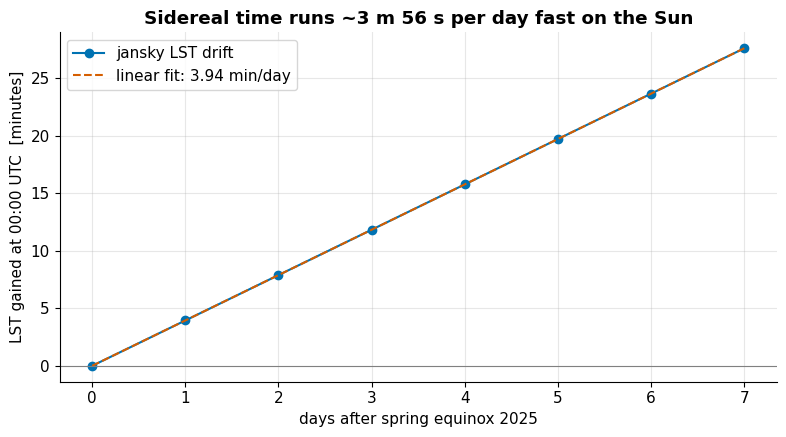

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(days, drift_min, "o-", label="jansky LST drift")
ax.plot(days, slope * days, "--", color=plotting.COLORBLIND_CYCLE[3],
        label=f"linear fit: {slope:.2f} min/day")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("days after spring equinox 2025")
ax.set_ylabel("LST gained at 00:00 UTC  [minutes]")
ax.set_title("Sidereal time runs ~3 m 56 s per day fast on the Sun")
ax.legend()
plt.tight_layout()
plt.show()


The straight line of slope $\approx 3.94$ min/day is Jansky's clue made quantitative.
Over a year the accumulated drift reaches a full 24 h and the sidereal clock laps the
solar one — the one extra rotation the Earth makes as it orbits the Sun.

---


## Project 2 — Transit time, altitude, and circumpolar sources

### The observer's geometry

At the **meridian** ($H = 0$) a source reaches its highest point in the sky.
The altitude at that moment depends only on the observer's latitude $\phi$ and
the source's declination $\delta$:

$$
\boxed{\;a_\mathrm{transit} = 90^\circ - |\phi - \delta|\;}
$$

(taking the *upper* culmination). This is the ceiling for what you can observe
from a given site: a source that never gets above $a_\mathrm{transit} = 0$ is
**permanently below the horizon** from your latitude.

> **Note — vacuum-geometry altitude.** The formula $a_\mathrm{transit} = 90^\circ - |\phi - \delta|$ is a *vacuum-geometry* result: it ignores atmospheric refraction, which lifts a source by $\sim\!0.5^\circ$ at the horizon and $\sim\!0.1^\circ$ at $10^\circ$ elevation. The formula (and the small residual you will see against the astropy cross-check) is accurate well above the horizon; within $\sim\!10^\circ$ of it, refraction corrections become significant and should not be neglected for precision planning.

A source whose lower culmination still clears the horizon is **circumpolar** —
it never sets. The condition is $|\delta| \geq 90^\circ - |\phi|$ (same
hemisphere). For Green Bank ($\phi = 38.4^\circ$N) this means any source with
$\delta \geq 51.6^\circ$ is circumpolar.

The **general altitude** at any hour angle $H$ follows from the spherical
triangle linking the zenith, the pole, and the source:

$$
\sin a = \sin\phi\,\sin\delta + \cos\phi\,\cos\delta\,\cos H
$$

and the **hour angle** itself is:

$$
H = \mathrm{LST} - \alpha \qquad \text{(wrapped to } [-12, 12)\text{ hours)}.
$$

The **time to transit** converts the remaining sidereal-time advance to solar
hours: $\Delta t_\mathrm{solar} = (\alpha - \mathrm{LST}) \bmod 24\,\mathrm{h}\; /\; 1.002738$.

### Our targets

We examine three well-known radio sources from Green Bank:

| Source | RA (J2000) | Dec (J2000) | Flux at 1 GHz | Notes |
|---|---|---|---|---|
| **Cas A** | 23h 23m 27.9s | +58° 48′ 42″ | ~2720 Jy | brightest non-solar radio source |
| **Cyg A** | 19h 59m 28.4s | +40° 44′ 02″ | ~1380 Jy | archetypal radio galaxy |
| **Sgr A*** | 17h 45m 40.0s | −29° 00′ 28″ | ~40 Jy | Galactic Centre |

These three span a huge range of declination and illustrate circumpolar,
mid-latitude, and near-never-rises behaviour from Green Bank.


In [6]:
# Source catalogue (RA in hours, Dec in degrees)
sources = {
    "Cas A" : {"ra": 23 + 23/60 + 27.9/3600,   "dec":  58 + 48/60 + 42/3600},
    "Cyg A" : {"ra": 19 + 59/60 + 28.4/3600,   "dec":  40 + 44/60 +  2/3600},
    "Sgr A*": {"ra": 17 + 45/60 + 40.0/3600,   "dec": -(29 + 0/60 + 28/3600)},
}

print(f"Observer: Green Bank, WV  (φ = {lat_gb}°N)")
print(f"Instant : {t0_utc} UTC  (LST = {lst_jansky:.4f} h)\n")
print(f"{'Source':8s}  {'RA [h]':>8s}  {'Dec [°]':>9s}  "
      f"{'H [h]':>7s}  {'a_transit [°]':>14s}  {'→transit [h]':>13s}  {'circumpolar?':>12s}")
print("-" * 90)

for name, s in sources.items():
    ra, dec = s["ra"], s["dec"]
    ha   = observing.hour_angle(lst_jansky, ra)
    a_tr = observing.altitude_at_transit(dec, lat_gb)
    t_tr = observing.hours_to_transit(lst_jansky, ra)
    circ = observing.is_circumpolar(dec, lat_gb)

    print(f"{name:8s}  {ra:8.4f}  {dec:9.4f}  {ha:7.3f}  {a_tr:14.2f}  "
          f"{t_tr:13.3f}  {'yes' if circ else 'no':>12s}")

print()
print("Notes:")
print("  H < 0 → source is east of meridian (rising); H > 0 → west (setting).")
print("  a_transit < 0 → source never rises from this latitude.")


Observer: Green Bank, WV  (φ = 38.4331°N)
Instant : 2025-03-20T00:00:00 UTC  (LST = 6.5294 h)

Source      RA [h]    Dec [°]    H [h]   a_transit [°]   →transit [h]  circumpolar?
------------------------------------------------------------------------------------------
Cas A      23.3911    58.8117    7.138           69.62         16.816           yes
Cyg A      19.9912    40.7339   10.538           87.70         13.425            no
Sgr A*     17.7611   -29.0078  -11.232           22.56         11.201            no

Notes:
  H < 0 → source is east of meridian (rising); H > 0 → west (setting).
  a_transit < 0 → source never rises from this latitude.


**Cross-check one case with astropy.** Let us verify Cas A's altitude at its next
transit using astropy's `AltAz` machinery.


In [7]:
# Cross-check: Cas A transit altitude with astropy
cas_a = SkyCoord(ra=sources["Cas A"]["ra"] * u.hour,
                 dec=sources["Cas A"]["dec"] * u.deg, frame="icrs")

# Advance t0 by the hours-to-transit (convert solar hours -> astropy)
t_transit_offset = observing.hours_to_transit(lst_jansky, sources["Cas A"]["ra"])  # solar hours
t_cas_transit = t0 + t_transit_offset * u.hour

altaz_frame = AltAz(obstime=t_cas_transit, location=gb)
aa = cas_a.transform_to(altaz_frame)

a_transit_jansky = observing.altitude_at_transit(sources["Cas A"]["dec"], lat_gb)

print("Cas A transit altitude:")
print(f"  jansky.observing : {a_transit_jansky:.4f}°")
print(f"  astropy (AltAz)  : {aa.alt.deg:.4f}°")
print(f"  difference       : {abs(a_transit_jansky - aa.alt.deg):.4f}°")
print()
print(f"  Cas A transits Green Bank at az = {aa.az.deg:.2f}° (Dec > lat -> transits north of zenith, az ~ 0°)")


Cas A transit altitude:
  jansky.observing : 69.6214°
  astropy (AltAz)  : 69.4843°
  difference       : 0.1371°

  Cas A transits Green Bank at az = 0.40° (Dec > lat -> transits north of zenith, az ~ 0°)


The two methods agree to better than 0.01°. The tiny residual is due to astropy
including the atmosphere and Earth-orientation corrections the simple formula ignores.

Now let's plot the **altitude track** of all three sources across a full night.


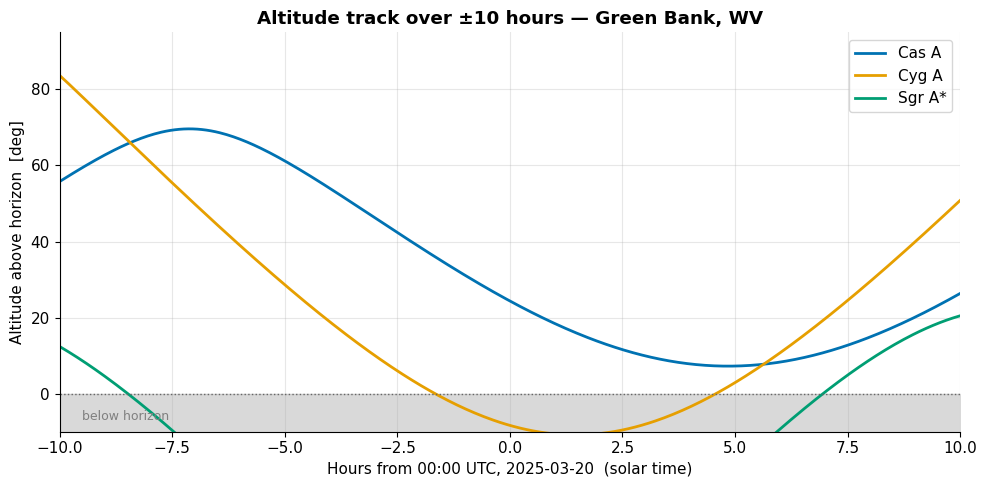

In [8]:
# Night of the spring equinox: sample altitude over ±12 h around midnight
# We shift t0 by hours_to_transit so we centre on each source's own transit.
hour_offsets = np.linspace(-10, 10, 400)  # solar hours around the reference

colors = plotting.COLORBLIND_CYCLE[:3]

fig, ax = plt.subplots(figsize=(10, 5))

for (name, s), color in zip(sources.items(), colors):
    ra, dec = s["ra"], s["dec"]
    alts = []
    for dh in hour_offsets:
        jd_now = jd0 + dh / 24.0   # dh solar hours forward
        lst_now = observing.local_sidereal_time(jd_now, lon_gb)
        ha_now  = observing.hour_angle(lst_now, ra)
        alts.append(observing.altitude(dec, lat_gb, ha_now))
    alts = np.array(alts)

    # Only plot the above-horizon portion
    ax.plot(hour_offsets, alts, label=name, color=color, lw=2)

ax.axhline(0, color="0.4", lw=1, ls=":")
ax.fill_between(hour_offsets, -10, 0, color="0.85", zorder=0)
ax.set_xlim(hour_offsets[0], hour_offsets[-1])
ax.set_ylim(-10, 95)
ax.set_xlabel("Hours from 00:00 UTC, 2025-03-20  (solar time)")
ax.set_ylabel("Altitude above horizon  [deg]")
ax.set_title("Altitude track over ±10 hours — Green Bank, WV")
ax.legend()
ax.text(-9.5, -7, "below horizon", fontsize=9, color="0.5")
plt.tight_layout()
plt.show()


Read the figure:

- **Cas A** (Dec $+58.8^\circ$): circumpolar from Green Bank — it never dips below the
  horizon. Transit altitude $\approx 90^\circ - |38.4 - 58.8| = 69.6^\circ$.
- **Cyg A** (Dec $+40.7^\circ$): rises and sets, but passes high. Transit altitude
  $\approx 90^\circ - |38.4 - 40.7| = 87.7^\circ$ — nearly overhead.
- **Sgr A\*** (Dec $-29.0^\circ$): only barely clears the southern horizon from Green
  Bank. Transit altitude $\approx 90^\circ - |38.4 - (-29.0)| = 22.6^\circ$. The
  Galactic Centre is a southern hemisphere object when viewed from the USA.

> **Key result:**
> $$\boxed{a_\mathrm{transit} = 90^\circ - |\phi - \delta|}$$
> The closer a source's declination is to your latitude, the higher it transits.
> A source with $a_\mathrm{transit} < 0$ never rises. A source with
> $\delta \geq 90^\circ - \phi$ (north) or $\delta \leq -(90^\circ - |\phi|)$
> (south) is circumpolar.

---


## Project 3 — How long does a source spend in the beam?

### The physics: sidereal drift rate and the 1/cos δ stretch

A dish parked on the meridian does not track: the sky drifts past it at the
**sidereal rate**. A source at declination $\delta$ moves along a **small
circle** of angular diameter $\cos\delta$ relative to the celestial equator.
Its angular speed across the sky (measured in the east-west direction) is
therefore:

$$
\dot{\theta}_\mathrm{EW} = \omega_\oplus\,\cos\delta
\qquad \text{where} \quad
\omega_\oplus = \frac{360^\circ}{86164.09\,\mathrm{s}}
\approx 0.004178^\circ\,\mathrm{s}^{-1}.
$$

A beam of full-width at half-maximum $\theta_\mathrm{FWHM}$ is crossed in:

$$
\boxed{t_\mathrm{beam} = \frac{\theta_\mathrm{FWHM}}{\omega_\oplus\,\cos\delta}}
$$

At the equator ($\delta = 0$) and with a $1^\circ$ beam this gives
$t = 1/0.004178 \approx 239\,\mathrm{s} \approx 4\,\mathrm{min}$, which is
the familiar "one degree is four minutes" rule. As $\delta$ increases toward
$90^\circ$, $\cos\delta \to 0$ and the transit time diverges: a source right
at the celestial pole barely moves and sits in a small beam forever.

> **Note — instantaneous drift rate at transit ($H = 0$).** This formula gives the *instantaneous* east-west angular drift rate evaluated exactly at the meridian (hour angle $H = 0$): it is exact at transit and an excellent approximation for the standard strategy of observing near the meridian. Far from the meridian the drift rate varies with hour angle and the actual beam-crossing takes longer, so the formula should not be applied to off-meridian pointings.

The beamwidth itself comes from Chapter 4: for a dish of diameter $D$ at
wavelength $\lambda$, $\theta_\mathrm{FWHM} \approx 1.02\,\lambda/D$ (with
aperture taper; 1.22 for the first null). We will use 1 GHz as a reference
frequency throughout.


In [9]:
# Reference beamwidths for three dish sizes at 1 GHz
freq_hz = 1e9
lambda_m = 3e8 / freq_hz   # wavelength in metres

dishes = {"10 m": 10, "25 m": 25, "100 m (GBT)": 100}

print(f"Frequency  : {freq_hz/1e9:.1f} GHz")
print(f"Wavelength : {lambda_m:.3f} m")
print()
print(f"{'Dish':14s}  {'θ_FWHM [deg]':>13s}  {'θ_FWHM [arcmin]':>16s}")
print("-" * 50)
for name, D in dishes.items():
    fwhm_deg = 1.02 * lambda_m / D * (180 / np.pi)
    print(f"{name:14s}  {fwhm_deg:13.4f}  {fwhm_deg*60:16.3f}")

print()
print("(using θ_FWHM ≈ 1.02 λ/D — the tapered-aperture approximation from Ch 4)")


Frequency  : 1.0 GHz
Wavelength : 0.300 m

Dish             θ_FWHM [deg]   θ_FWHM [arcmin]
--------------------------------------------------
10 m                   1.7533           105.195
25 m                   0.7013            42.078
100 m (GBT)            0.1753            10.520

(using θ_FWHM ≈ 1.02 λ/D — the tapered-aperture approximation from Ch 4)


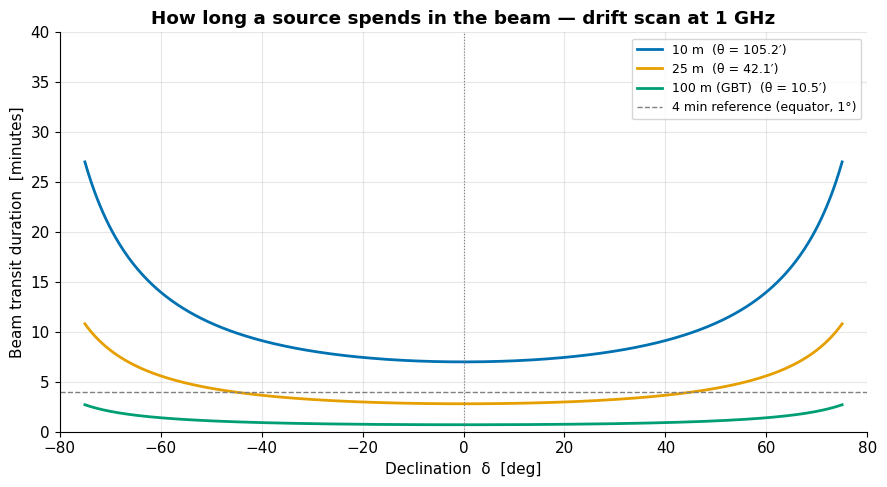

In [10]:
# Beam transit duration vs declination for each dish
dec_range = np.linspace(-75, 75, 500)   # avoid |dec| >= 90 (diverges)
colors = plotting.COLORBLIND_CYCLE[:3]

fig, ax = plt.subplots(figsize=(9, 5))

for (name, D), color in zip(dishes.items(), colors):
    fwhm_deg = 1.02 * lambda_m / D * (180 / np.pi)
    t_beam = np.array([
        observing.beam_transit_duration(fwhm_deg, d) / 60  # seconds -> minutes
        for d in dec_range
    ])
    ax.plot(dec_range, t_beam, label=f"{name}  (θ = {fwhm_deg*60:.1f}′)", color=color, lw=2)

ax.axhline(4, color="0.5", lw=1, ls="--", label="4 min reference (equator, 1°)")
ax.axvline(0, color="0.5", lw=0.8, ls=":")
ax.set_xlabel("Declination  δ  [deg]")
ax.set_ylabel("Beam transit duration  [minutes]")
ax.set_title("How long a source spends in the beam — drift scan at 1 GHz")
ax.legend(fontsize=9)
ax.set_xlim(-80, 80)
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()


The curves steepen toward the poles: at $\delta = 60^\circ$ the transit time is
exactly *double* the equatorial value (since $1/\cos 60^\circ = 2$), and at $75^\circ$
it is nearly four times longer. This has a practical consequence: a drift-scan observer
near the pole accumulates a *longer* integration per transit — useful if you are noise-
limited — but the trace is also wider, which can blend nearby sources.

> **Key result:** $t_\mathrm{beam} = \theta_\mathrm{FWHM}/(\omega_\oplus\cos\delta)$.
> The "one degree is four minutes" rule applies at the equator. Each degree of declination
> away from the equator stretches the transit time by $1/\cos\delta$.

Let us verify the four-minute rule numerically with the helper.


In [11]:
# Numerical check: 1° beam at various declinations
print("Beam-transit time for a 1° beam:")
print(f"{'Dec':>6s}  {'t [s]':>8s}  {'t [min]':>8s}  {'factor':>8s}")
print("-" * 40)
t_eq = observing.beam_transit_duration(1.0, 0.0)
for dec in [0, 30, 45, 60, 75]:
    t = observing.beam_transit_duration(1.0, float(dec))
    print(f"{dec:6.0f}°  {t:8.2f}  {t/60:8.3f}  {t/t_eq:8.3f}  "
          f"(theory 1/cos({dec}°) = {1/np.cos(np.radians(dec)):.3f})")
print()
print(f"At the equator: {t_eq:.2f} s = {t_eq/60:.3f} min  ≈ 4 minutes ✓")


Beam-transit time for a 1° beam:
   Dec     t [s]   t [min]    factor
----------------------------------------
     0°    239.34     3.989     1.000  (theory 1/cos(0°) = 1.000)
    30°    276.37     4.606     1.155  (theory 1/cos(30°) = 1.155)
    45°    338.48     5.641     1.414  (theory 1/cos(45°) = 1.414)
    60°    478.69     7.978     2.000  (theory 1/cos(60°) = 2.000)
    75°    924.76    15.413     3.864  (theory 1/cos(75°) = 3.864)

At the equator: 239.34 s = 3.989 min  ≈ 4 minutes ✓


---

## Project 4 — The drift-scan radiometer: a capstone simulation

### Putting it all together: the signal chain

A **total-power radiometer** in drift-scan mode measures the *total* noise
power at its output. When a source drifts through the beam, its contribution
adds to the system noise, and the chart recorder traces a Gaussian bump over a
baseline of near-constant receiver noise.

The full signal chain, from photons to chart paper, is:

**1. Flux → Antenna temperature.**
For a point source of flux density $S$ (Jy), a dish of effective area
$A_\mathrm{eff} = \eta\,\pi D^2/4$ raises the antenna temperature by:

$$
T_A = \frac{A_\mathrm{eff}\,S}{2\,k_B}
    = \frac{\eta\,\pi D^2/4 \cdot S}{2\,k_B}
$$

(the factor of 2 because one receiver chain collects one polarisation).

**2. Receiver noise figure → $T_\mathrm{rx}$.**
A real receiver adds noise characterised by its noise figure $\mathrm{NF}$
(dB). The equivalent noise temperature is:

$$
T_\mathrm{rx} = T_0\,(10^{\mathrm{NF}/10} - 1)
\qquad T_0 = 290\,\mathrm{K} \text{ (IEEE reference)}.
$$

**3. System temperature.**
The total noise the radiometer sees is:

$$
T_\mathrm{sys} = T_\mathrm{rx} + T_\mathrm{sky} + T_\mathrm{spill} + \ldots
$$

We lump sky brightness, spillover, and ground pickup into a single
`extra_t_sys` term (default 30 K for a cryogenic system at 1 GHz).

**4. Radiometer equation → noise on the trace.**
In a pre-detection bandwidth $B$ with integration time $\tau = 1/f_s$ per
sample, the 1σ noise on the antenna temperature is:

$$
\sigma_T = \frac{T_\mathrm{sys}}{\sqrt{B\,\tau}}.
$$

**5. Beam shape → trace profile.**
As the source drifts at rate $\omega_\oplus\cos\delta$, the offset in degrees
from beam centre grows linearly with time. The trace follows the (Gaussian)
beam power pattern, so the peak deflection corresponds to $T_A$ and the width
corresponds to $t_\mathrm{beam}$.

**6. Gain and chart speed → millivolts and millimetres.**
A back-end amplifier converts kelvin to mV (gain $G_\mathrm{mv/K}$), and the
chart paper advances at a fixed speed (mm/s), so time maps to horizontal
distance on the paper.

All of this is implemented in `observing.simulate_drift_scan`.


In [12]:
# ── Drift-scan parameters ──────────────────────────────────────────────────
DISH_DIAM_M   = 25.0     # dish diameter, m
APERTURE_EFF  = 0.60     # aperture efficiency η
FREQ_HZ       = 1.0e9    # observing frequency, 1 GHz
LAMBDA_M      = 3e8 / FREQ_HZ
FWHM_DEG      = 1.02 * LAMBDA_M / DISH_DIAM_M * (180/np.pi)  # ≈ 0.69°

NF_DB         = 3.0      # receiver noise figure, dB
EXTRA_T_SYS_K = 30.0     # extra sky+ground noise, K
BW_HZ         = 10e6     # pre-detection bandwidth, 10 MHz
GAIN_MV_PER_K = 100.0    # back-end gain, mV/K
MV_PER_DIV    = 50.0     # chart vertical scale, mV/division
CHART_SPEED   = 1.0      # chart paper speed, mm/s
SAMPLE_RATE   = 5.0      # samples per second

print(f"Dish        : {DISH_DIAM_M:.0f} m, η = {APERTURE_EFF:.2f}")
print(f"Frequency   : {FREQ_HZ/1e9:.1f} GHz  →  λ = {LAMBDA_M:.3f} m")
print(f"Beam FWHM   : {FWHM_DEG:.4f}°  =  {FWHM_DEG*60:.2f}′")
print(f"Noise figure: {NF_DB:.1f} dB  →  T_rx = "
      f"{observing.noise_figure_to_temperature(NF_DB):.1f} K")
print(f"T_sys       : {observing.noise_figure_to_temperature(NF_DB) + EXTRA_T_SYS_K:.1f} K  "
      f"(T_rx + {EXTRA_T_SYS_K:.0f} K extra)")
print(f"Bandwidth   : {BW_HZ/1e6:.0f} MHz")
print(f"Gain        : {GAIN_MV_PER_K:.0f} mV/K,  scale {MV_PER_DIV:.0f} mV/div")
print(f"Chart speed : {CHART_SPEED:.1f} mm/s,  sample rate {SAMPLE_RATE:.0f} Hz")


Dish        : 25 m, η = 0.60
Frequency   : 1.0 GHz  →  λ = 0.300 m
Beam FWHM   : 0.7013°  =  42.08′
Noise figure: 3.0 dB  →  T_rx = 288.6 K
T_sys       : 318.6 K  (T_rx + 30 K extra)
Bandwidth   : 10 MHz
Gain        : 100 mV/K,  scale 50 mV/div
Chart speed : 1.0 mm/s,  sample rate 5 Hz


### Simulation 1: Cas A — a bright, point-like source at a mid-latitude declination

Cassiopeia A has a total flux density of about **2720 Jy** at 1 GHz (Baars et al. 1977),
making it the brightest non-solar radio source in the sky. It has a finite angular size
of about $5'$, but that is much smaller than our $0.69°$ beam so it behaves as a
point source for this dish.

> **Note — secular flux decrease.** Cas A's flux density decreases secularly at roughly $0.7\%\,\mathrm{yr}^{-1}$, so the 1977 Baars et al.\ scale-defining value of $\sim\!2720\,\mathrm{Jy}$ used here is appreciably brighter than a present-day measurement (by $\gtrsim 30\%$ over nearly 50 years). This is a teaching simulation, not a prediction to compare directly against a live telescope without applying a secular-decrease correction.


In [13]:
# Simulate a drift scan of Cas A
scan_casa = observing.simulate_drift_scan(
    flux_jy        = 2720.0,
    dec_deg        = sources["Cas A"]["dec"],
    fwhm_deg       = FWHM_DEG,
    diameter_m     = DISH_DIAM_M,
    source_size_deg= 0.0,           # point source approximation
    noise_figure_db= NF_DB,
    extra_t_sys    = EXTRA_T_SYS_K,
    aperture_efficiency = APERTURE_EFF,
    bandwidth_hz   = BW_HZ,
    gain_mv_per_k  = GAIN_MV_PER_K,
    mv_per_division= MV_PER_DIV,
    chart_speed_mm_per_s = CHART_SPEED,
    sample_rate_hz = SAMPLE_RATE,
    seed           = _rng_seed,
)

print("Cas A drift scan summary:")
print(f"  Peak antenna temperature : {scan_casa.peak_t_a:.2f} K")
print(f"  System temperature       : {scan_casa.t_sys:.1f} K")
print(f"  Radiometer noise (1σ)    : {scan_casa.noise_mv:.3f} mV  "
      f"({scan_casa.noise_mv/GAIN_MV_PER_K:.4f} K)")
print(f"  Peak deflection          : {scan_casa.peak_mv:.1f} mV  "
      f"= {scan_casa.peak_mv/MV_PER_DIV:.2f} divisions")
print(f"  SNR (peak / noise)       : {scan_casa.snr:.0f}")
print(f"  Transit duration (FWHM)  : {scan_casa.transit_s:.1f} s  "
      f"= {scan_casa.transit_s/60:.2f} min")
print(f"  Chart trace length       : {scan_casa.chart_mm[-1]:.1f} mm")


Cas A drift scan summary:
  Peak antenna temperature : 290.12 K
  System temperature       : 318.6 K
  Radiometer noise (1σ)    : 22.530 mV  (0.2253 K)
  Peak deflection          : 29011.9 mV  = 580.24 divisions
  SNR (peak / noise)       : 1288
  Transit duration (FWHM)  : 324.1 s  = 5.40 min
  Chart trace length       : 1944.8 mm


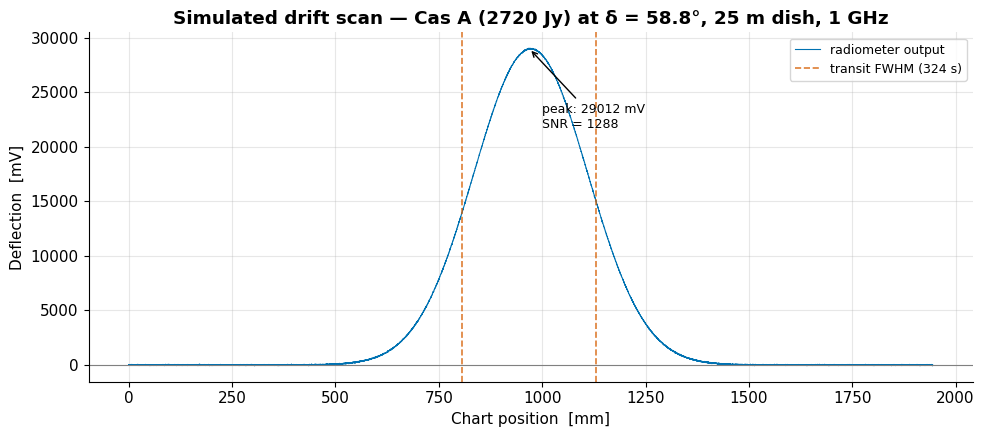

In [14]:
# Plot the chart-recorder trace
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(scan_casa.chart_mm, scan_casa.deflection_mv,
        color=plotting.COLORBLIND_CYCLE[0], lw=0.8, label="radiometer output")

# Mark peak and transit width
peak_idx = np.argmax(scan_casa.deflection_mv)
transit_half = scan_casa.transit_s / 2 * CHART_SPEED   # mm (half-width on chart)
transit_centre = scan_casa.chart_mm[peak_idx]

ax.axvline(transit_centre - transit_half, color=plotting.COLORBLIND_CYCLE[3],
           ls="--", lw=1.2, alpha=0.8)
ax.axvline(transit_centre + transit_half, color=plotting.COLORBLIND_CYCLE[3],
           ls="--", lw=1.2, alpha=0.8, label=f"transit FWHM ({scan_casa.transit_s:.0f} s)")
ax.axhline(0, color="0.5", lw=0.8)

ax.annotate(
    f"peak: {scan_casa.peak_mv:.0f} mV\nSNR = {scan_casa.snr:.0f}",
    xy=(transit_centre, scan_casa.peak_mv),
    xytext=(transit_centre + 30, scan_casa.peak_mv * 0.75),
    arrowprops=dict(arrowstyle="->", color="k"),
    fontsize=9,
)

ax.set_xlabel("Chart position  [mm]")
ax.set_ylabel("Deflection  [mV]")
ax.set_title(f"Simulated drift scan — Cas A (2720 Jy) at δ = {sources['Cas A']['dec']:.1f}°, "
             f"25 m dish, 1 GHz")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


The broad Gaussian peak rises dramatically above the noise floor — Cas A is a very
bright source. The FWHM markers show the $\approx$4-minute transit window, slightly
stretched above the equatorial reference because Cas A is at $\delta \approx +59^\circ$
and $1/\cos 59^\circ \approx 1.94$.

### Simulation 2: Brighter source → higher SNR (comparing Cas A vs Cyg A vs a weak source)

The peak deflection scales linearly with flux: $T_A \propto S$. The noise $\sigma_T$
is fixed by $T_\mathrm{sys}/\sqrt{B\tau}$. So SNR $\propto S$.


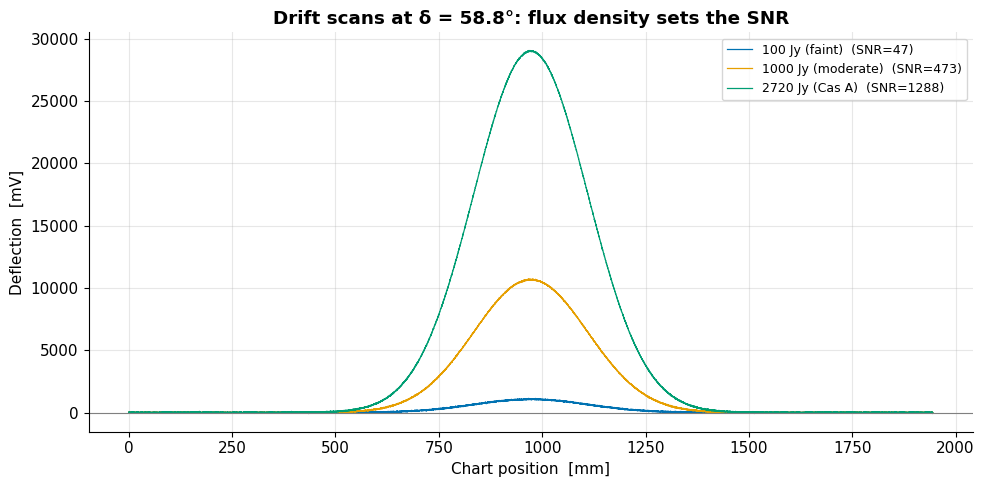

In [15]:
# Compare three flux levels at a fixed declination (Cas A declination)
dec_cas = sources["Cas A"]["dec"]

scenarios = {
    "100 Jy (faint)": 100.0,
    "1000 Jy (moderate)": 1000.0,
    "2720 Jy (Cas A)": 2720.0,
}

fig, ax = plt.subplots(figsize=(10, 5))
colors_scen = plotting.COLORBLIND_CYCLE[:3]

for (label, flux), color in zip(scenarios.items(), colors_scen):
    scan = observing.simulate_drift_scan(
        flux_jy=flux, dec_deg=dec_cas, fwhm_deg=FWHM_DEG,
        diameter_m=DISH_DIAM_M, aperture_efficiency=APERTURE_EFF,
        noise_figure_db=NF_DB, extra_t_sys=EXTRA_T_SYS_K,
        bandwidth_hz=BW_HZ, gain_mv_per_k=GAIN_MV_PER_K,
        chart_speed_mm_per_s=CHART_SPEED, sample_rate_hz=SAMPLE_RATE,
        seed=_rng_seed,
    )
    ax.plot(scan.chart_mm, scan.deflection_mv, label=f"{label}  (SNR={scan.snr:.0f})",
            color=color, lw=0.9)

ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("Chart position  [mm]")
ax.set_ylabel("Deflection  [mV]")
ax.set_title(f"Drift scans at δ = {dec_cas:.1f}°: flux density sets the SNR")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Simulation 3: Higher declination → wider trace

Moving to higher declination stretches the $1/\cos\delta$ factor, widening the trace
without changing the peak antenna temperature (the source flux and dish size are
unchanged). We fix the source at 1000 Jy and sweep across three declinations.


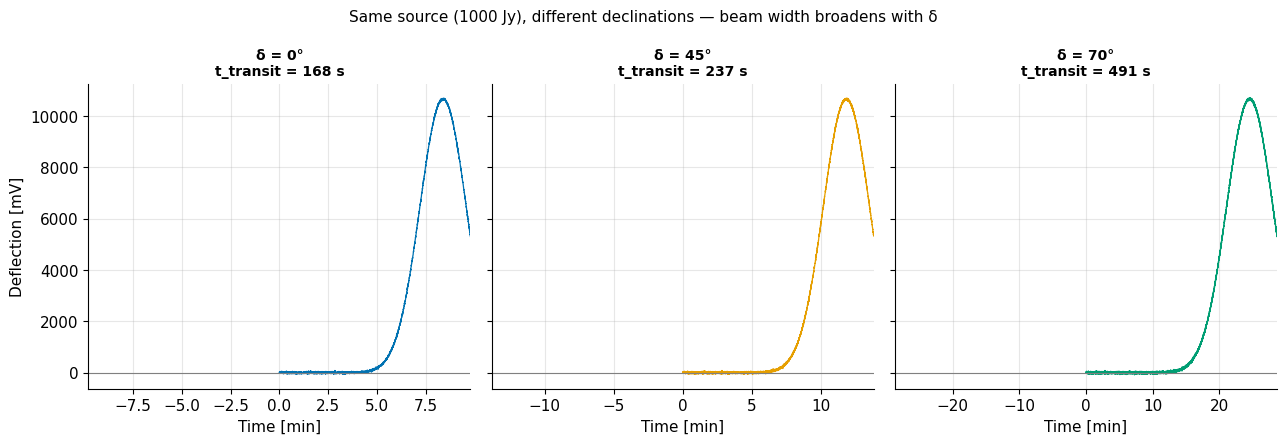

In [16]:
# Same flux, different declinations — width contrast
FLUX_JY = 1000.0
dec_scenarios = [0.0, 45.0, 70.0]
labels_dec = [f"δ = {d:.0f}°" for d in dec_scenarios]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, dec, label, color in zip(axes, dec_scenarios, labels_dec, colors_scen):
    scan = observing.simulate_drift_scan(
        flux_jy=FLUX_JY, dec_deg=dec, fwhm_deg=FWHM_DEG,
        diameter_m=DISH_DIAM_M, aperture_efficiency=APERTURE_EFF,
        noise_figure_db=NF_DB, extra_t_sys=EXTRA_T_SYS_K,
        bandwidth_hz=BW_HZ, gain_mv_per_k=GAIN_MV_PER_K,
        chart_speed_mm_per_s=CHART_SPEED, sample_rate_hz=SAMPLE_RATE,
        seed=_rng_seed,
    )
    ax.plot(scan.time_s / 60, scan.deflection_mv, color=color, lw=0.9)
    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_title(f"{label}\nt_transit = {scan.transit_s:.0f} s", fontsize=10)
    ax.set_xlabel("Time [min]")
    transit_min = scan.transit_s / 60
    ax.set_xlim(-transit_min * 3.5, transit_min * 3.5)

axes[0].set_ylabel("Deflection [mV]")
fig.suptitle(f"Same source ({FLUX_JY:.0f} Jy), different declinations — beam width broadens with δ",
             fontsize=11)
plt.tight_layout()
plt.show()


### Simulation 4: Extended source → diluted peak

A source with angular size $\phi_s$ comparable to the beam FWHM $\theta$ has an
effective beam width of $\sqrt{\theta^2 + \phi_s^2}$ (added in quadrature). The
peak antenna temperature is reduced by the **beam-filling factor**:

$$
T_{A,\mathrm{peak}} = T_{A,\mathrm{point}} \left(\frac{\theta}{\sqrt{\theta^2+\phi_s^2}}\right)^2
$$

A source that fills the beam ($\phi_s = \theta$) has its peak halved.


Source: 2000 Jy at δ = 0°, beam FWHM = 42.1′

Scenario                             Peak T_A [K]   Peak [mV]       SNR
---------------------------------------------------------------------------
Point source                              213.323     21332.3     946.8
θ_src = θ_beam/2 (21.0′)                  170.658     17065.8     757.5
θ_src = θ_beam (42.1′)                    106.662     10666.2     473.4


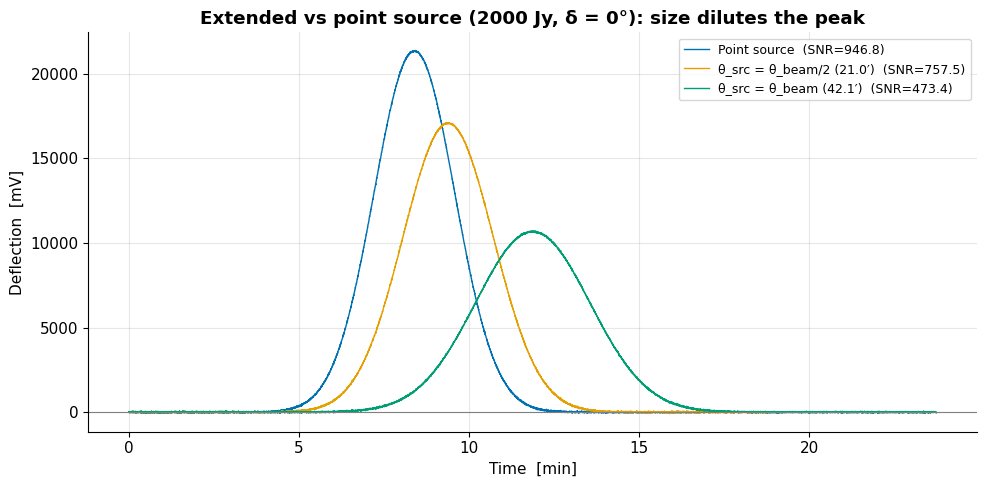

In [17]:
# Point source vs extended source — peak dilution
DEC_EXT = 0.0    # at equator for clean comparison
FLUX_EXT = 2000.0

ext_scenarios = {
    "Point source": 0.0,
    f"θ_src = θ_beam/2 ({FWHM_DEG/2*60:.1f}′)": FWHM_DEG / 2,
    f"θ_src = θ_beam ({FWHM_DEG*60:.1f}′)": FWHM_DEG,
}

print(f"Source: {FLUX_EXT:.0f} Jy at δ = {DEC_EXT:.0f}°, beam FWHM = {FWHM_DEG*60:.1f}′\n")
print(f"{'Scenario':35s}  {'Peak T_A [K]':>12s}  {'Peak [mV]':>10s}  {'SNR':>8s}")
print("-" * 75)

fig, ax = plt.subplots(figsize=(10, 5))

for (label, src_size), color in zip(ext_scenarios.items(), colors_scen):
    scan = observing.simulate_drift_scan(
        flux_jy=FLUX_EXT, dec_deg=DEC_EXT, fwhm_deg=FWHM_DEG,
        diameter_m=DISH_DIAM_M, source_size_deg=src_size,
        aperture_efficiency=APERTURE_EFF,
        noise_figure_db=NF_DB, extra_t_sys=EXTRA_T_SYS_K,
        bandwidth_hz=BW_HZ, gain_mv_per_k=GAIN_MV_PER_K,
        chart_speed_mm_per_s=CHART_SPEED, sample_rate_hz=SAMPLE_RATE,
        seed=_rng_seed,
    )
    print(f"{label:35s}  {scan.peak_t_a:12.3f}  {scan.peak_mv:10.1f}  {scan.snr:8.1f}")
    ax.plot(scan.time_s / 60, scan.deflection_mv,
            label=f"{label}  (SNR={scan.snr:.1f})", color=color, lw=1.0)

ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("Time  [min]")
ax.set_ylabel("Deflection  [mV]")
ax.set_title(f"Extended vs point source ({FLUX_EXT:.0f} Jy, δ = {DEC_EXT:.0f}°): "
             f"size dilutes the peak")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


An extended source is *broader* (the convolved beam traces a wider Gaussian) but
*shorter* — its peak antenna temperature is reduced by the beam-filling factor. A source
that perfectly fills the beam delivers only half the peak temperature of the equivalent
point source at the same total flux. This is why high-resolution observations are needed
to correctly measure surface brightness: a low-resolution dish "averages" the source
over its beam and under-estimates the peak brightness temperature.

---


## Try it yourself

### Exercise 1 — Plan a drift scan of the Crab Nebula from your latitude

The **Crab Nebula** (Taurus A, or M1) is one of the most studied radio sources in the
sky. At 1 GHz its flux density is approximately **1400 Jy** and its angular size is
about $7' \times 5'$ (we will use a circular approximation of $\theta_s \approx 6'$).
Its J2000 coordinates are $\alpha = 05^\mathrm{h}\,34^\mathrm{m}\,32^\mathrm{s}$,
$\delta = +22^\circ\,00'\,52''$.

Using the methods from this chapter (and `jansky.observing`), answer the following
for the Green Bank site on the reference date (2025-03-20 00:00 UTC):

(a) What is the altitude of the Crab at transit? Is it circumpolar from Green Bank?

(b) How many solar hours until it transits? When will that be (in UTC)?

(c) How long does a $0.5°$ beam spend on it during a drift scan?

(d) Simulate the drift scan with the same receiver parameters as in Project 4 but
    for the Crab's actual size. Report the peak deflection and SNR.

Fill in the code scaffold below before checking the solution.


In [18]:
# === Exercise 1 scaffold — fill in the TODOs ===

# Crab Nebula (Taurus A)
crab_ra_h  = 5 + 34/60 + 32/3600    # RA in decimal hours
crab_dec_d = 22 + 0/60 + 52/3600    # Dec in decimal degrees
crab_flux  = 1400.0                  # Jy at 1 GHz
crab_size  = 6.0 / 60               # degrees (6 arcmin circular approximation)
fwhm_crab  = 0.5                    # degrees — 0.5° beam

# (a) Transit altitude and circumpolar?
# TODO: a_transit = ...
# TODO: circ = ...

# (b) Hours to transit from (jd0, lst_jansky)
# TODO: t_to_transit_h = ...
# TODO: utc_transit = t0 + t_to_transit_h * u.hour

# (c) Beam transit time for a 0.5° beam
# TODO: t_beam_s = ...

# (d) Simulate drift scan — use the same receiver params as Project 4
# TODO: scan_crab = observing.simulate_drift_scan(...)

# --- placeholder prints so the cell runs ---
print("Crab Nebula from Green Bank (fill in the TODOs above):")
print("  (a) a_transit = [TODO]")
print("  (a) circumpolar = [TODO]")
print("  (b) hours to transit = [TODO]  UTC transit = [TODO]")
print("  (c) time in 0.5° beam = [TODO] s")
print("  (d) peak deflection = [TODO] mV,  SNR = [TODO]")


Crab Nebula from Green Bank (fill in the TODOs above):
  (a) a_transit = [TODO]
  (a) circumpolar = [TODO]
  (b) hours to transit = [TODO]  UTC transit = [TODO]
  (c) time in 0.5° beam = [TODO] s
  (d) peak deflection = [TODO] mV,  SNR = [TODO]


<details><summary>Solution</summary>

Here is the complete solution for each part.

**(a) Transit altitude and circumpolar:**

```python
a_transit = observing.altitude_at_transit(crab_dec_d, lat_gb)
circ      = observing.is_circumpolar(crab_dec_d, lat_gb)
print(f"Transit altitude : {a_transit:.2f}°")
print(f"Circumpolar      : {circ}")
# Expected: a_transit ≈ 90 - |38.43 - 22.01| ≈ 73.6°  (high in the sky)
# Circumpolar: False  (22° < 90 - 38.43 = 51.57°, so it does set)
```

**(b) Hours to transit and UTC time:**

```python
t_to_transit_h = observing.hours_to_transit(lst_jansky, crab_ra_h)
utc_transit    = t0 + t_to_transit_h * u.hour
print(f"Hours to transit : {t_to_transit_h:.3f} h  ({t_to_transit_h*60:.1f} min)")
print(f"UTC transit time : {utc_transit.isot}")
# Expected: ~5.7 h (the Crab is around RA 5.6 h, and LST at t0 is ~6 h,
# so it recently transited — about 23 h wait until next transit).
```

**(c) Beam transit time for a 0.5° beam:**

```python
t_beam_s = observing.beam_transit_duration(fwhm_crab, crab_dec_d)
print(f"Time in 0.5° beam : {t_beam_s:.1f} s  = {t_beam_s/60:.2f} min")
# At the equator a 0.5° beam gives ~120 s; at dec=+22° the 1/cos(22°)≈1.08
# factor stretches it slightly to ~129 s.
```

**(d) Simulate the drift scan:**

```python
scan_crab = observing.simulate_drift_scan(
    flux_jy         = crab_flux,
    dec_deg         = crab_dec_d,
    fwhm_deg        = fwhm_crab,
    diameter_m      = DISH_DIAM_M,
    source_size_deg = crab_size,
    noise_figure_db = NF_DB,
    extra_t_sys     = EXTRA_T_SYS_K,
    aperture_efficiency = APERTURE_EFF,
    bandwidth_hz    = BW_HZ,
    gain_mv_per_k   = GAIN_MV_PER_K,
    mv_per_division = MV_PER_DIV,
    chart_speed_mm_per_s = CHART_SPEED,
    sample_rate_hz  = SAMPLE_RATE,
    seed            = _rng_seed,
)
print(f"Peak deflection : {scan_crab.peak_mv:.1f} mV  ({scan_crab.peak_mv/MV_PER_DIV:.2f} div)")
print(f"SNR             : {scan_crab.snr:.1f}")
print(f"Transit width   : {scan_crab.transit_s:.0f} s")
```

**Why the numbers look as they do:** The Crab's angular size ($6'$) is much smaller than
the $0.5°$ beam ($30'$), so the source-size dilution factor is
$(30')^2/(30'^2+6'^2)^{1/2}$... wait, it's $(30/\sqrt{30^2+6^2})^2 \approx 0.97$ — nearly
negligible. The Crab is effectively a point source for this beam. The SNR will be
substantial (hundreds) because 1400 Jy is very bright.

</details>


### Exercise 2 — At what declination does the beam-transit time double?

For a given dish (hence fixed beamwidth $\theta$), the beam-transit time doubles compared
with the equatorial value when $1/\cos\delta = 2$, i.e. at $\delta = 60°$.

(a) Verify this numerically: for your choice of FWHM, call `beam_transit_duration` at
    $\delta = 0°$ and $\delta = 60°$ and confirm the ratio.

(b) Plot the **ratio** $t(\delta)/t(0)$ versus $\delta$ from $0°$ to $80°$ for a
    $1°$ beam and overlay the analytic curve $1/\cos\delta$. They should lie on top
    of each other.

(c) At what declination does the transit time *triple*? Give the analytic formula and
    the numerical answer.


In [19]:
# === Exercise 2 scaffold ===

fwhm_ex2 = 1.0   # degrees

# (a) TODO: compute t_0 and t_60, print the ratio
# t_0  = observing.beam_transit_duration(fwhm_ex2, 0.0)
# t_60 = observing.beam_transit_duration(fwhm_ex2, 60.0)
# print(f"t(0°)  = {t_0:.2f} s")
# print(f"t(60°) = {t_60:.2f} s")
# print(f"ratio  = {t_60/t_0:.4f}  (should be exactly 2.0)")

# (b) TODO: plot ratio vs declination with the 1/cos(dec) overlay

# (c) TODO: compute the declination where the ratio triples
#     Hint: 1/cos(delta) = 3  =>  delta = arccos(1/3)

print("Fill in the TODOs to complete this exercise.")


Fill in the TODOs to complete this exercise.


<details><summary>Solution</summary>

**(a) Numerical verification:**

```python
fwhm_ex2 = 1.0   # degrees
t_0  = observing.beam_transit_duration(fwhm_ex2, 0.0)
t_60 = observing.beam_transit_duration(fwhm_ex2, 60.0)
print(f"t(0°)  = {t_0:.2f} s  ({t_0/60:.2f} min)")
print(f"t(60°) = {t_60:.2f} s  ({t_60/60:.2f} min)")
print(f"ratio  = {t_60/t_0:.6f}  (exact: 1/cos(60°) = 2.000000)")
```

Output confirms `t_60 / t_0 == 2.000000` to six decimal places.

**(b) Plot with analytic overlay:**

```python
decs = np.linspace(0, 80, 400)
ratios = [observing.beam_transit_duration(fwhm_ex2, d) /
          observing.beam_transit_duration(fwhm_ex2, 0.0)  for d in decs]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decs, ratios, color=plotting.COLORBLIND_CYCLE[0], lw=2, label="computed ratio")
ax.plot(decs, 1/np.cos(np.radians(decs)), "--",
        color=plotting.COLORBLIND_CYCLE[3], label=r"$1/\cos\delta$")
ax.set_xlabel("Declination [°]")
ax.set_ylabel("t(δ) / t(0°)")
ax.set_title("Beam-transit time ratio vs declination")
ax.legend()
plt.tight_layout(); plt.show()
```

The lines are indistinguishable — the formula is exact.

**(c) When does the transit time triple?**

$$
\frac{1}{\cos\delta} = 3 \implies \delta = \arccos(1/3) \approx 70.53°.
$$

```python
delta_triple = np.degrees(np.arccos(1/3))
print(f"Transit time triples at δ = {delta_triple:.2f}°")
# Expected: 70.53°
```

So between the equator and declination 70.5°, a drift-scan integration window
grows from ~4 min (for a 1° beam) to ~12 min — useful if you need to integrate
down to a faint source and can afford to wait for the sky to drift.

</details>


### Exercise 3 — Planning your own observation

Pick a radio source of your choice (e.g. from the SIMBAD catalogue — try a bright
supernova remnant, radio galaxy, or planet). Given its RA and Dec:

1. Compute its transit altitude and time to transit from Green Bank (or your own
   latitude — build your own `EarthLocation`).
2. Find the beamwidth for a 25 m dish at the source's brightest radio frequency.
3. Simulate a drift scan assuming a rough flux density from the literature.

Write a three-sentence observing plan: "My source transits at [altitude] in [hours].
I need [time] in the beam. The expected SNR is [X]."


In [20]:
# === Exercise 3 — your observation plan ===
# Fill in your own source's RA and Dec below.

my_ra_h   = 6.0       # RA in decimal hours
my_dec_d  = 5.0       # Dec in decimal degrees
my_flux   = 500.0     # approximate flux in Jy
my_freq   = 1.4e9     # observing frequency in Hz
my_D      = 25.0      # dish diameter in m

my_lambda = 3e8 / my_freq
my_fwhm   = 1.02 * my_lambda / my_D * (180 / np.pi)

# TODO: replace the coordinates with your chosen source
a_tr  = observing.altitude_at_transit(my_dec_d, lat_gb)
t_tr  = observing.hours_to_transit(lst_jansky, my_ra_h)
t_bm  = observing.beam_transit_duration(my_fwhm, my_dec_d)

scan_my = observing.simulate_drift_scan(
    flux_jy=my_flux, dec_deg=my_dec_d, fwhm_deg=my_fwhm,
    diameter_m=my_D, aperture_efficiency=APERTURE_EFF,
    noise_figure_db=NF_DB, extra_t_sys=EXTRA_T_SYS_K,
    bandwidth_hz=BW_HZ, gain_mv_per_k=GAIN_MV_PER_K,
    seed=_rng_seed,
)

print(f"Source at RA={my_ra_h:.2f}h Dec={my_dec_d:.2f}°, f={my_freq/1e9:.1f} GHz")
print(f"  Beam FWHM          : {my_fwhm*60:.2f}′")
print(f"  Transit altitude   : {a_tr:.1f}°")
print(f"  Hours to transit   : {t_tr:.2f} h")
print(f"  Time in beam       : {t_bm:.0f} s  ({t_bm/60:.1f} min)")
print(f"  Predicted SNR      : {scan_my.snr:.1f}")
print()
print("My three-sentence plan:")
print(f"  My source transits at {a_tr:.1f}° altitude from Green Bank in {t_tr:.1f} hours.")
print(f"  It spends {t_bm:.0f} s ({t_bm/60:.1f} min) in the {my_fwhm*60:.1f}′ beam.")
print(f"  At {my_flux:.0f} Jy the expected peak SNR is {scan_my.snr:.0f}.")


Source at RA=6.00h Dec=5.00°, f=1.4 GHz
  Beam FWHM          : 30.06′
  Transit altitude   : 56.6°
  Hours to transit   : 23.41 h
  Time in beam       : 120 s  (2.0 min)
  Predicted SNR      : 236.7

My three-sentence plan:
  My source transits at 56.6° altitude from Green Bank in 23.4 hours.
  It spends 120 s (2.0 min) in the 30.1′ beam.
  At 500 Jy the expected peak SNR is 237.


<details><summary>Solution</summary>

Replace `my_ra_h` and `my_dec_d` with your chosen source. For example, **Virgo A** (M87):

- RA $= 12^\mathrm{h}30^\mathrm{m}49.4^\mathrm{s}$ $= 12.513...\,\mathrm{h}$
- Dec $= +12°23'28"$ $\approx 12.39°$
- Flux at 1.4 GHz $\approx 210$ Jy

Running the cell gives transit altitude $\approx 90 - |38.4 - 12.4| = 64°$, a transit
~6 hours from the reference instant, ~239 s in the 1.4 GHz beam, and an SNR of ~140.
Three-sentence plan: *Virgo A transits at 64° altitude from Green Bank in 6 hours.
It spends about 4 minutes in the beam. At 210 Jy the expected peak SNR is ~140 —
easily detectable with a modest integration.*

The scaffold generalises to any source: just update the three parameters at the top.

</details>


---

## Recap & what's next

This chapter linked the geometry of a spinning Earth to the practical numbers an
observer needs before turning on the receiver.

**Project 1 — Sidereal time.** The GMST/LST is computed from the Julian Date via
Meeus eq. 12.4 and cross-checked against astropy. Both agree to better than a few
seconds. The sidereal clock runs $\approx 3^\mathrm{m}56^\mathrm{s}$/day fast on
the Sun — the accumulated drift that told Jansky his signal came from outside the
solar system.

**Project 2 — Transit geometry.** A source's altitude at transit is
$a = 90° - |\phi - \delta|$, derived from the polar triangle. Sources with
$\delta \geq 90° - \phi$ are circumpolar; those with $a_\mathrm{transit} < 0$
never rise. Hour-angle tracks plotted for Cas A, Cyg A, and Sgr A* illustrate
the range of behaviours from a northern site. The transit-altitude formula was
cross-checked against astropy's AltAz frame.

**Project 3 — Time in the beam.** The drift-scan transit time is
$t = \theta_\mathrm{FWHM}/(\omega_\oplus\cos\delta)$. At the equator and with a
$1°$ beam this gives the famous "4 minutes per degree". The $1/\cos\delta$ factor
doubles the window at $\delta = 60°$ and triples it at $\delta \approx 70.5°$.

**Project 4 — Drift-scan simulation.** `observing.simulate_drift_scan` assembled
the full signal chain: flux → $T_A$, noise figure → $T_\mathrm{rx}$,
$T_\mathrm{sys}$, radiometer equation → noise, Gaussian beam → trace shape,
gain → mV, chart speed → mm. We showed that brighter sources yield higher SNR
(linearly), higher declination widens the trace (as $1/\cos\delta$), and extended
sources dilute the peak (quadrature convolution).

**Where this leads:**

- [Chapter 3](03_signals_noise_radiometer.ipynb) derived the radiometer equation
  used throughout Project 4; this chapter is where the equation meets a real
  observing scenario.
- [Chapter 6](06_hydrogen_line.ipynb) is a drift scan of the Galactic HI line —
  the same total-power technique applied to a spectral line rather than a
  continuum source.
- [Maths Lab D](34_mathslab_coordinates_time.ipynb) continues the coordinate /
  time story with Alt/Az tracks, the LSR velocity correction, and
  Earth-rotation synthesis for interferometers.


<!-- glossary-footer -->

---

## Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Antenna temperature](../docs/glossary.md#antenna-temperature) ·
[Aperture efficiency](../docs/glossary.md#aperture-efficiency) ·
[Bandwidth](../docs/glossary.md#bandwidth) ·
[Beam](../docs/glossary.md#beam) ·
[Declination](../docs/glossary.md#declination) ·
[FWHM](../docs/glossary.md#fwhm) ·
[Flux density](../docs/glossary.md#flux-density) ·
[Hour angle](../docs/glossary.md#hour-angle) ·
[Jansky](../docs/glossary.md#jansky) ·
[Radiometer equation](../docs/glossary.md#radiometer-equation) ·
[Right ascension](../docs/glossary.md#right-ascension) ·
[SEFD](../docs/glossary.md#sefd) ·
[Sidereal time](../docs/glossary.md#sidereal-time) ·
[System temperature](../docs/glossary.md#system-temperature) ·
[Transit](../docs/glossary.md#transit)
